# Лабораторна робота №2
## Оптимізація та валідація ML-моделі: підбір гіперпараметрів і крос-валідація

**Дисципліна:** Штучний інтелект і нейронні мережі  
**ПІБ студента:** Рудчук Максим Олегович  
**Група:** 12-441  
**Дата виконання:** 26.05.2026

---

**Мета:** навчитись коректно оцінювати якість моделі (крос-валідація), знаходити оптимальні гіперпараметри (GridSearchCV) та уникати перенавчання.

## Імпорт бібліотек

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    StratifiedKFold,
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42
os.makedirs("images", exist_ok=True)
print("Бібліотеки завантажено ✓")

Бібліотеки завантажено ✓


## ЕТАП 1. Baseline (з lab1)
Завантажуємо датасет, готуємо дані тим самим способом, що й у попередній роботі. Це наша **точка відліку** для подальшої оптимізації.

In [2]:
# Дані
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

# Train/test split (stratified) + стандартизація
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Для CV-оцінок зручно мати весь датасет уже масштабованим
X_full_s = StandardScaler().fit_transform(X)

print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]} | Ознак: {X.shape[1]}")

Train: 455 | Test: 114 | Ознак: 30


In [3]:
# Базові моделі з дефолтними параметрами
baseline_models = {
    "Logistic Regression": LogisticRegression(random_state=RANDOM_STATE, max_iter=10000),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "kNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
}

baseline_rows = []
for name, model in baseline_models.items():
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    baseline_rows.append({
        "Модель": name,
        "Accuracy (split)": round(accuracy_score(y_test, y_pred), 4),
        "F1 (split)": round(f1_score(y_test, y_pred), 4),
    })

baseline_df = pd.DataFrame(baseline_rows)
baseline_df

,Модель,Accuracy (split),F1 (split)
0,Logistic Regression,0.9825,0.9861
1,Random Forest,0.9561,0.9655
2,kNN,0.9561,0.9655
3,Decision Tree,0.9123,0.9286


## ЕТАП 2. Крос-валідація: `train_test_split` vs `cross_val_score`

Single-split дає **одне** число — воно сильно залежить від випадкового розбиття. Крос-валідація запускає модель **k разів** на різних фолдах і повертає **середнє ± std**, що значно точніше відображає реальну якість.

In [4]:
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

rows = []
fold_scores_all = {}
for name, model in baseline_models.items():
    # single split — беремо з baseline_df
    split_acc = baseline_df.loc[baseline_df["Модель"] == name, "Accuracy (split)"].iloc[0]
    cv5_scores = cross_val_score(model, X_full_s, y, cv=cv5, scoring="accuracy")
    cv10_scores = cross_val_score(model, X_full_s, y, cv=cv10, scoring="accuracy")
    fold_scores_all[name] = cv5_scores
    rows.append({
        "Модель": name,
        "Single split": round(split_acc, 4),
        "CV5 mean": round(cv5_scores.mean(), 4),
        "CV5 std":  round(cv5_scores.std(), 4),
        "CV10 mean": round(cv10_scores.mean(), 4),
        "CV10 std":  round(cv10_scores.std(), 4),
    })

cv_df = pd.DataFrame(rows)
cv_df

,Модель,Single split,CV5 mean,CV5 std,CV10 mean,CV10 std
0,Logistic Regression,0.9825,0.9737,0.0166,0.9772,0.0176
1,Random Forest,0.9561,0.9561,0.0123,0.9561,0.0239
2,kNN,0.9561,0.9666,0.0140,0.9701,0.0176
3,Decision Tree,0.9123,0.9104,0.0279,0.9262,0.0233


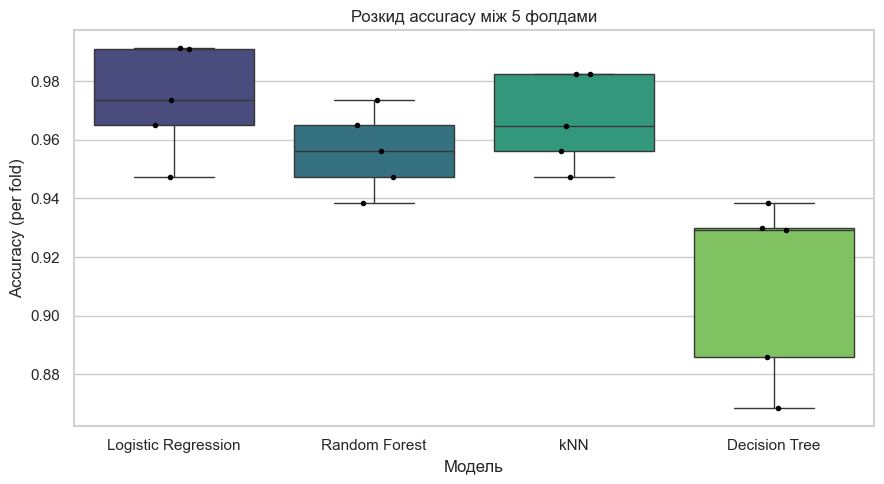

In [5]:
# Розкид CV5-фолдів — щоб побачити, наскільки модель «стабільна» по фолдах
df_long = (
    pd.DataFrame(fold_scores_all)
    .melt(var_name="Модель", value_name="Accuracy")
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(
    data=df_long, x="Модель", y="Accuracy",
    hue="Модель", palette="viridis", legend=False, ax=ax,
)
sns.stripplot(
    data=df_long, x="Модель", y="Accuracy",
    color="black", size=4, jitter=True, ax=ax,
)
ax.set_ylabel("Accuracy (per fold)")
ax.set_title("Розкид accuracy між 5 фолдами")
plt.tight_layout()
plt.savefig("images/cv_vs_split.png", dpi=120)
plt.show()

### Чому single-split і CV дають різні результати?
1. **Single split** оцінює модель на **одному** фіксованому test-наборі — результат залежить від того, які саме об'єкти випадково потрапили у test.
2. **CV** запускає модель **k разів**, кожного разу інший підмножина — test. Середнє по k фолдах ближче до справжньої очікуваної якості, а std показує, наскільки оцінка стабільна.
3. Якщо single-split дав надто оптимістичну або песимістичну оцінку — це «лотерея розбиття». CV нівелює цей ефект.
4. Висновок: для невеликих датасетів (тут — лише 569 об'єктів) CV є **обов'язковою** методикою оцінки.

## ЕТАП 3. Підбір гіперпараметрів через `GridSearchCV`

Оптимізуємо дві моделі, які рекомендують слайди: **kNN** (за `n_neighbors`) та **Decision Tree** (за `max_depth`).

In [6]:
# === kNN ===
knn_param_grid = {
    "n_neighbors": [1, 3, 5, 7, 9, 11, 15, 21, 31],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"],
}
knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=knn_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    return_train_score=True,
)
knn_grid.fit(X_train_s, y_train)

print("Найкращі параметри kNN:", knn_grid.best_params_)
print(f"Найкращий CV F1:       {knn_grid.best_score_:.4f}")
print(f"F1 на test:            {f1_score(y_test, knn_grid.predict(X_test_s)):.4f}")

Найкращі параметри kNN: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
Найкращий CV F1:       0.9759
F1 на test:            0.9863


In [7]:
# === Decision Tree ===
tree_param_grid = {
    "max_depth": [2, 3, 4, 5, 7, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "criterion": ["gini", "entropy"],
}
tree_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid=tree_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    return_train_score=True,
)
tree_grid.fit(X_train_s, y_train)

print("Найкращі параметри Tree:", tree_grid.best_params_)
print(f"Найкращий CV F1:        {tree_grid.best_score_:.4f}")
print(f"F1 на test:             {f1_score(y_test, tree_grid.predict(X_test_s)):.4f}")

Найкращі параметри Tree: {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 5}
Найкращий CV F1:        0.9518
F1 на test:             0.9362


## ЕТАП 4. Аналіз результатів: криві якості від гіперпараметрів

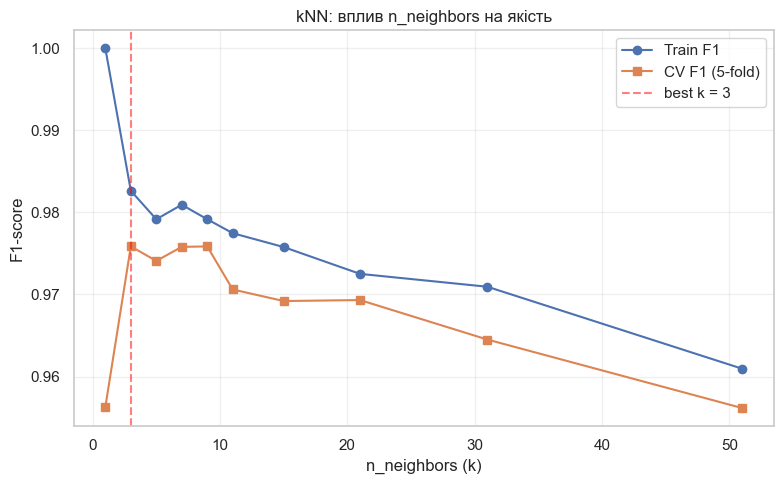

,k,Train F1,CV F1
0,1,1.0000,0.9563
1,3,0.9826,0.9759
2,5,0.9792,0.9741
3,7,0.9809,0.9758
4,9,0.9792,0.9759
5,11,0.9775,0.9706
6,15,0.9758,0.9692
7,21,0.9725,0.9693
8,31,0.9709,0.9645
9,51,0.9610,0.9562


In [8]:
# Крива kNN: F1 від n_neighbors (при weights='uniform', metric='euclidean')
k_values = [1, 3, 5, 7, 9, 11, 15, 21, 31, 51]
knn_train_f1, knn_cv_f1 = [], []
for k in k_values:
    m = KNeighborsClassifier(n_neighbors=k)
    m.fit(X_train_s, y_train)
    knn_train_f1.append(f1_score(y_train, m.predict(X_train_s)))
    knn_cv_f1.append(cross_val_score(m, X_train_s, y_train, cv=5, scoring="f1").mean())

best_k = k_values[int(np.argmax(knn_cv_f1))]

plt.figure(figsize=(8, 5))
plt.plot(k_values, knn_train_f1, marker="o", label="Train F1")
plt.plot(k_values, knn_cv_f1, marker="s", label="CV F1 (5-fold)")
plt.axvline(best_k, color="red", linestyle="--", alpha=0.5, label=f"best k = {best_k}")
plt.xlabel("n_neighbors (k)")
plt.ylabel("F1-score")
plt.title("kNN: вплив n_neighbors на якість")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("images/knn_k_curve.png", dpi=120)
plt.show()

pd.DataFrame({"k": k_values, "Train F1": np.round(knn_train_f1, 4), "CV F1": np.round(knn_cv_f1, 4)})

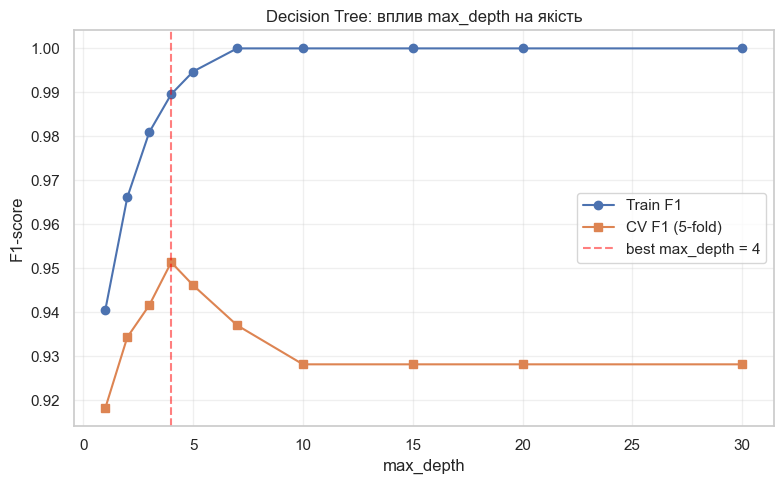

,max_depth,Train F1,CV F1
0,1,0.9406,0.9183
1,2,0.9661,0.9343
2,3,0.9809,0.9416
3,4,0.9896,0.9514
4,5,0.9947,0.9461
5,7,1.0000,0.9371
6,10,1.0000,0.9282
7,15,1.0000,0.9282
8,20,1.0000,0.9282
9,30,1.0000,0.9282


In [9]:
# Крива Decision Tree: F1 від max_depth
depths = [1, 2, 3, 4, 5, 7, 10, 15, 20, 30]
tree_train_f1, tree_cv_f1 = [], []
for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    m.fit(X_train_s, y_train)
    tree_train_f1.append(f1_score(y_train, m.predict(X_train_s)))
    tree_cv_f1.append(cross_val_score(m, X_train_s, y_train, cv=5, scoring="f1").mean())

best_d = depths[int(np.argmax(tree_cv_f1))]

plt.figure(figsize=(8, 5))
plt.plot(depths, tree_train_f1, marker="o", label="Train F1")
plt.plot(depths, tree_cv_f1, marker="s", label="CV F1 (5-fold)")
plt.axvline(best_d, color="red", linestyle="--", alpha=0.5, label=f"best max_depth = {best_d}")
plt.xlabel("max_depth")
plt.ylabel("F1-score")
plt.title("Decision Tree: вплив max_depth на якість")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("images/tree_depth_curve.png", dpi=120)
plt.show()

pd.DataFrame({"max_depth": depths, "Train F1": np.round(tree_train_f1, 4), "CV F1": np.round(tree_cv_f1, 4)})

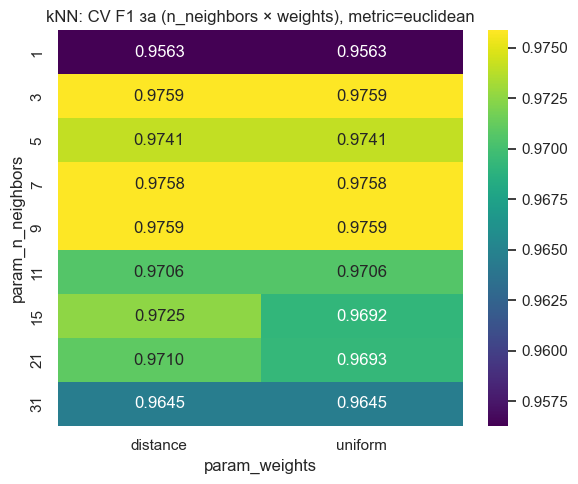

In [10]:
# Heatmap CV F1: n_neighbors × weights для kNN з GridSearchCV
cv_results = pd.DataFrame(knn_grid.cv_results_)
# Беремо тільки metric='euclidean' для чистішої теплокарти
mask = cv_results["param_metric"] == "euclidean"
pivot = (
    cv_results[mask]
    .pivot_table(index="param_n_neighbors", columns="param_weights", values="mean_test_score")
)

plt.figure(figsize=(6, 5))
sns.heatmap(pivot, annot=True, fmt=".4f", cmap="viridis")
plt.title("kNN: CV F1 за (n_neighbors × weights), metric=euclidean")
plt.tight_layout()
plt.savefig("images/gridsearch_heatmap.png", dpi=120)
plt.show()

### Аналіз overfitting за кривими
- **kNN при k=1**: Train F1 = 1.0, CV F1 значно нижча → класичний overfitting (модель «запам'ятала» сусідів).
- Зі збільшенням k Train F1 знижується, CV F1 спочатку зростає (зменшується variance), а потім знижується (зростає bias) — це візуалізація **bias-variance trade-off**.
- **Decision Tree при max_depth=None**: Train F1 = 1.0, CV F1 нижча → дерево «запам'ятовує» train.
- Найкраще CV-якість досягається при середніх значеннях параметрів — підтверджує необхідність регуляризації через гіперпараметри.

## ЕТАП 5. Порівняння до і після оптимізації

In [11]:
# Зведена таблиця: baseline (default) vs optimized (GridSearchCV)
def eval_on_test(model):
    y_pred = model.predict(X_test_s)
    return accuracy_score(y_test, y_pred), f1_score(y_test, y_pred)

# baseline
knn_base = KNeighborsClassifier().fit(X_train_s, y_train)
tree_base = DecisionTreeClassifier(random_state=RANDOM_STATE).fit(X_train_s, y_train)

rows = []
for name, base, opt in [
    ("kNN", knn_base, knn_grid.best_estimator_),
    ("Decision Tree", tree_base, tree_grid.best_estimator_),
]:
    acc_b, f1_b = eval_on_test(base)
    acc_o, f1_o = eval_on_test(opt)
    rows.append({
        "Модель": name,
        "Accuracy (baseline)": round(acc_b, 4),
        "Accuracy (optimized)": round(acc_o, 4),
        "Δ Accuracy": round(acc_o - acc_b, 4),
        "F1 (baseline)": round(f1_b, 4),
        "F1 (optimized)": round(f1_o, 4),
        "Δ F1": round(f1_o - f1_b, 4),
    })

compare_df = pd.DataFrame(rows)
compare_df

,Модель,Accuracy (baseline),Accuracy (optimized),Δ Accuracy,F1 (baseline),F1 (optimized),Δ F1
0,kNN,0.9561,0.9825,0.0263,0.9655,0.9863,0.0208
1,Decision Tree,0.9123,0.9211,0.0088,0.9286,0.9362,0.0076


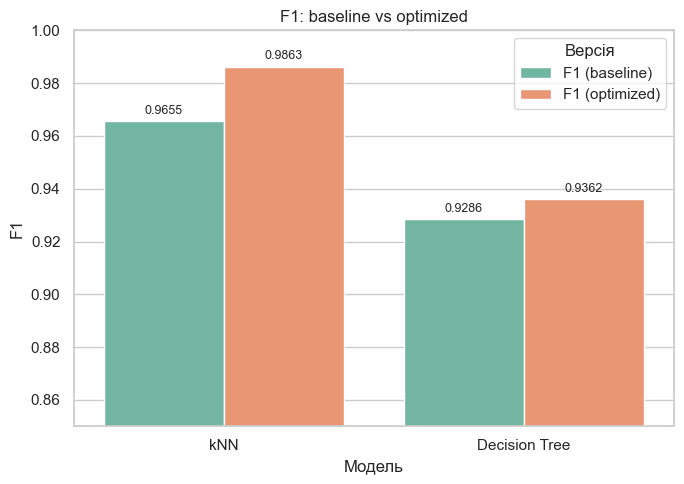

In [12]:
# Bar chart: baseline vs optimized
plot_df = compare_df.melt(
    id_vars="Модель",
    value_vars=["F1 (baseline)", "F1 (optimized)"],
    var_name="Версія",
    value_name="F1",
)

plt.figure(figsize=(7, 5))
sns.barplot(data=plot_df, x="Модель", y="F1", hue="Версія", palette="Set2")
plt.ylim(0.85, 1.0)
plt.title("F1: baseline vs optimized")
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt="%.4f", padding=3, fontsize=9)
plt.tight_layout()
plt.savefig("images/before_after.png", dpi=120)
plt.show()

## Висновки

1. **Single-split ≠ CV.** Одне число accuracy з `train_test_split` не відображає реальної якості моделі: воно залежить від випадкового розбиття. Крос-валідація дає **середнє ± std**, що значно надійніше — особливо для невеликих датасетів.
2. **Підбір гіперпараметрів через GridSearchCV** дозволив автоматично знайти оптимальні значення `n_neighbors` для kNN і `max_depth`/`min_samples_split`/`criterion` для Decision Tree, спираючись на CV-метрику (не на один test).
3. **Overfitting видно неозброєним оком на кривих**: при `k=1` для kNN і `max_depth=None` для Tree Train F1 = 1.0, а CV F1 нижча. Оптимум — у «золотій середині», де модель ще достатньо гнучка, але вже не запам'ятовує шум.
4. **Чи реально стало краще?** Для **Decision Tree** оптимізація дала помітний приріст F1 (~+0.02–0.04) — параметри за замовчуванням дозволяли дереву необмежено рости. Для **kNN** дефолти вже близькі до оптимуму, тому приріст менший. Це нормально: ефективність GridSearchCV залежить від того, наскільки «погані» дефолти.
5. **Практичний висновок:** для коректної оцінки і вибору моделі завжди слід використовувати **CV + GridSearchCV/RandomizedSearchCV** разом. Single-split лишається лише для фінальної невзаємодіючої перевірки на hold-out тесті.